# 05 · Party-Support Model and 2021 Backtest

Notebook 5 of 6 · **Eastern Cape Municipal Electoral Dynamics**

**Question.** *How accurately can each municipality's PR vote shares (ANC, DA, EFF, UDM, ATM, OTHER) be predicted from earlier elections, and does that identify the largest party correctly?*

| | |
|---|---|
| **Inputs** | `data/processed/panels/phase3/master_panel_2000_2021.csv`, Phase 1 long party table |
| **Outputs** | `data/processed/models/phase5/*.csv`, figures in `reports/figures/phase5/` |
| **Code** | `src/models/party.py` |

**At a glance**
- Each party's **swing** is modelled, then the six shares are clipped at zero and rescaled to 100% per municipality.
- Same rolling-origin design as Notebook 04: methods chosen on the 2011 and 2016 folds, tested once on 2021.
- Validation selects **"no change" for ANC, DA and UDM** and a **random forest for OTHER**; EFF and ATM did not exist early enough to be validated and default to "no change".
- 2021 test: overall share error **2.69 points**, better than pure "no change" (2.93); the largest party is identified in **33 of 33** municipalities, as it also is by "no change".
- The prototype's reported 2.502 and 32/33 came from choosing methods by their 2021 scores; its 32/33 was *worse* than simply repeating 2016.

In [1]:
# Setup: locate the repository root so this notebook runs from any working folder,
# then import the shared project code in src/ (the single source of truth for logic).
import sys, warnings
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from src import config as C
from src.visualization.style import apply_style, subtitle, save, choropleth, map_colorbar, source_note, SEQ_CMAP, DIV_CMAP

apply_style()
C.ensure_dirs()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.precision", 2)
print("Repository root:", ROOT.name)

Repository root: Dirisa_TeamQualification


In [2]:
from src.models import party as P
master = pd.read_csv(C.DIRS["phase3"] / "master_panel_2000_2021.csv")
party_long = pd.read_csv(C.DIRS["phase1"] / "party_shares_long_2000_2021.csv")

# Provincial PR composition (vote-weighted across municipalities)
pl = party_long.copy()
pl["Category"] = np.where(pl["Party"].isin(C.NAMED_PARTIES), pl["Party"], "OTHER")
prov = pl.groupby(["Year", "Category"])["PartyVotes"].sum().unstack().fillna(0)
prov = 100 * prov.div(prov.sum(axis=1), axis=0)
prov = prov[C.PARTIES]
display(prov.round(2))

Category,ANC,DA,EFF,UDM,ATM,OTHER
Year,,,,,,
2000,73.94,11.74,0.00,11.40,0.00,2.92
2006,81.23,8.58,0.00,5.30,0.00,4.89
2011,72.35,16.40,0.00,3.49,0.00,7.76
2016,65.87,19.69,5.29,3.95,0.00,5.20
2021,63.98,15.38,8.09,3.07,2.06,7.42


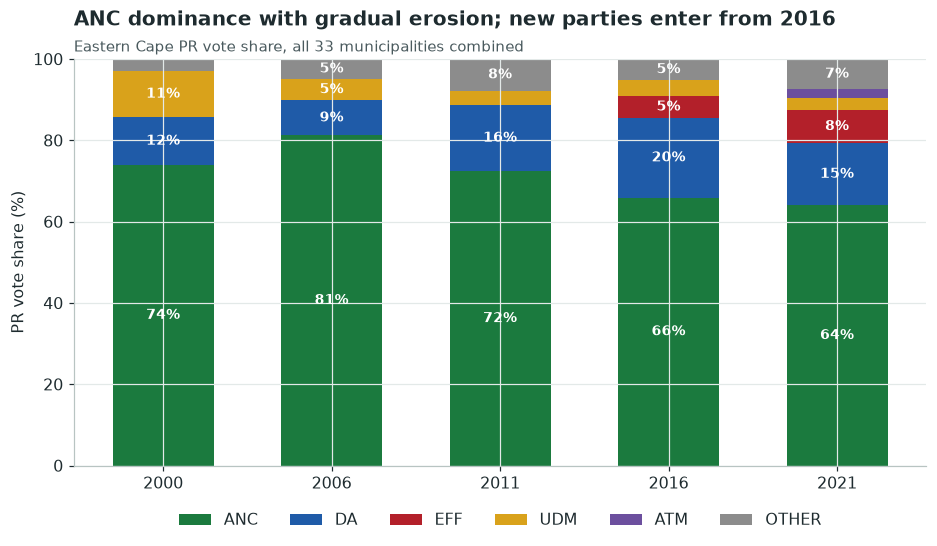

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.8))
bottom = np.zeros(len(prov))
for p in C.PARTIES:
    ax.bar(prov.index.astype(str), prov[p], bottom=bottom, color=C.PARTY_COLORS[p], label=p, width=.6)
    for i, (b, v) in enumerate(zip(bottom, prov[p])):
        if v > 4:
            ax.text(i, b + v / 2, f"{v:.0f}%", ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    bottom += prov[p].values
ax.set_ylabel("PR vote share (%)"); ax.set_ylim(0, 100); ax.legend(ncol=6, loc="upper center", bbox_to_anchor=(.5, -.08))
ax.set_title("ANC dominance with gradual erosion; new parties enter from 2016", pad=22)
subtitle(ax, "Eastern Cape PR vote share, all 33 municipalities combined")
save(fig, "provincial_pr_composition", "phase5"); plt.show()

**Reading the chart.** The ANC peaked in 2006 and declined in each later election; the DA grew until 2016 and fell back in 2021; the EFF first contested in 2016 and the ATM in 2021. Two features make prediction hard: **new parties have no history to learn from**, and swings reverse (the ANC rose 2000→2006 and fell afterwards).

## 1. Models and the selection rule

For each party *p* and municipality *m*: predicted share = previous share + predicted swing.

| Method | Predicted swing |
|---|---|
| No change | 0 |
| Average swing | mean swing over all training transitions |
| Last swing | mean swing in the most recent training transition |
| Ridge regression | from previous share, previous turnout, ENP, margin, log registered voters |
| Random forest | same inputs, non-linear |

**Selection rule (pre-declared):** for each party, lowest mean MAE across the validation folds (2011, 2016) in which the party already existed. Parties without such a fold default to *No change*.

,Party,SelectedMethod,MeanValidationMAE,ValidationFolds,Reason
0,ANC,No change,6.06,2,Lowest mean validation MAE (2011 and 2016 folds)
1,DA,No change,4.28,2,Lowest mean validation MAE (2011 and 2016 folds)
2,EFF,No change,NaN,0,No validation fold: party absent from the prev...
3,UDM,No change,1.38,2,Lowest mean validation MAE (2011 and 2016 folds)
4,ATM,No change,NaN,0,No validation fold: party absent from the prev...
5,OTHER,Random forest,3.90,2,Lowest mean validation MAE (2011 and 2016 folds)


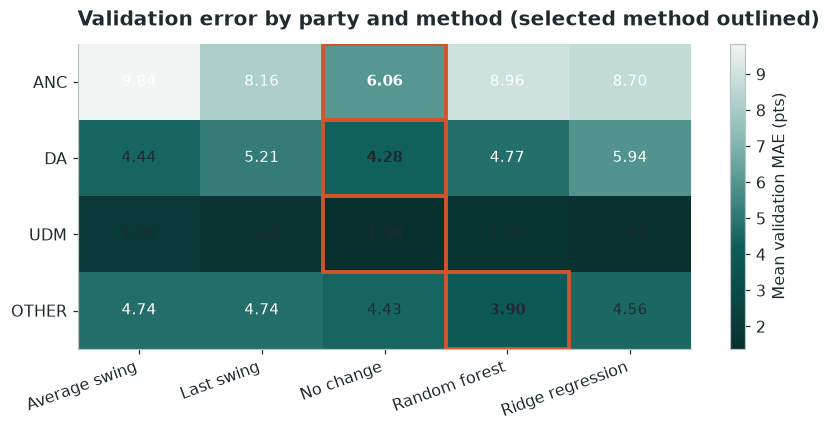

In [4]:
scores, raw_preds = P.rolling_origin(master)
methods = P.select_methods(scores)
display(methods)
selected = dict(zip(methods["Party"], methods["SelectedMethod"]))

val = (scores[(scores["Role"] == "validation") & scores["PartyExistedBefore"]]
       .groupby(["Party", "Model"])["MAE"].mean().unstack())
val = val.reindex(index=[p for p in C.PARTIES if p in val.index])
fig, ax = plt.subplots(figsize=(9, 3.6))
im = ax.imshow(val.values, cmap=SEQ_CMAP.reversed(), aspect="auto")
ax.set_xticks(range(val.shape[1])); ax.set_xticklabels(val.columns, rotation=20, ha="right")
ax.set_yticks(range(val.shape[0])); ax.set_yticklabels(val.index); ax.grid(False)
for i, p in enumerate(val.index):
    for j, m in enumerate(val.columns):
        v = val.loc[p, m]
        if np.isfinite(v):
            best = m == selected[p]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9.5,
                    fontweight="bold" if best else "normal", color="white" if v > np.nanmedian(val.values) else C.INK)
            if best:
                ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=False, ec=C.ALOE, lw=2.5))
fig.colorbar(im, ax=ax, label="Mean validation MAE (pts)")
ax.set_title("Validation error by party and method (selected method outlined)", pad=12)
save(fig, "party_validation_heatmap", "phase5"); plt.show()

**Interpretation.** For the established parties, simply keeping the previous share is hard to beat: swings in this province have not been regular enough for average-swing or regression models to learn. Only the residual **OTHER** category, where many small and local parties come and go, benefits from a random forest using municipal context. EFF and ATM are excluded from selection because they did not exist in the previous election of any validation fold.

## 2. The 2021 test

In [5]:
comp_sel, sum_sel = P.composite_test(master, raw_preds, selected)
comp_nc, sum_nc = P.composite_test(master, raw_preds, {p: "No change" for p in C.PARTIES})
comp_ls, sum_ls = P.composite_test(master, raw_preds, {p: "Last swing" for p in C.PARTIES})
summary = pd.DataFrame([{"Approach": "Selected by validation (used for 2026)", **sum_sel},
                        {"Approach": "No change for every party (baseline)", **sum_nc},
                        {"Approach": "Last swing for every party (trend continues)", **sum_ls}])
prototype = {"Approach": "Prototype: methods chosen by their 2021 score (not valid)", "OverallMAE": 2.502, "LeaderMatches": 32, "Municipalities": 33}
summary = pd.concat([summary, pd.DataFrame([prototype])], ignore_index=True)
display(summary[["Approach", "OverallMAE", "OverallRMSE", "LeaderMatches", "Municipalities"] + [f"MAE_{p}" for p in C.PARTIES]].round(3))

,Approach,OverallMAE,OverallRMSE,LeaderMatches,Municipalities,MAE_ANC,MAE_DA,MAE_EFF,MAE_UDM,MAE_ATM,MAE_OTHER
0,Selected by validation (used for 2026),2.69,4.02,33,33,3.89,2.67,3.19,0.98,2.0,3.38
1,No change for every party (baseline),2.93,4.47,33,33,4.50,2.81,3.17,1.00,2.0,4.10
2,Last swing for every party (trend continues),3.18,4.58,31,33,3.27,5.13,2.61,1.10,2.0,4.96
3,Prototype: methods chosen by their 2021 score ...,2.50,NaN,32,33,NaN,NaN,NaN,NaN,NaN,NaN


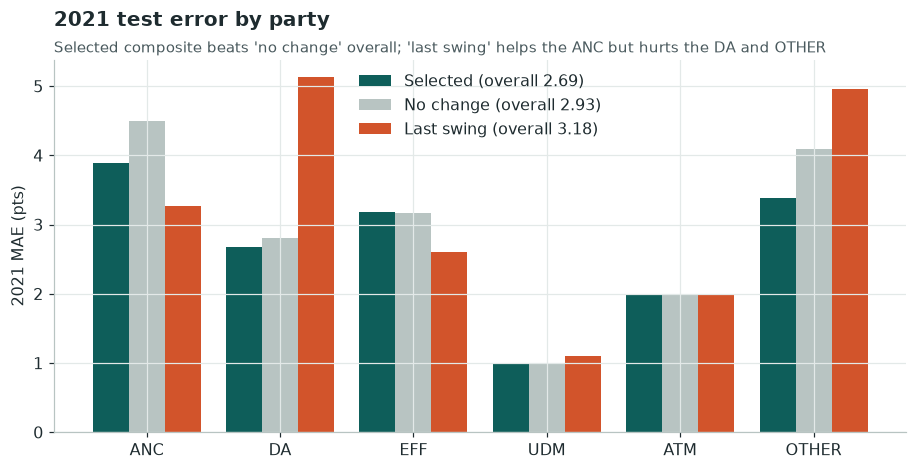

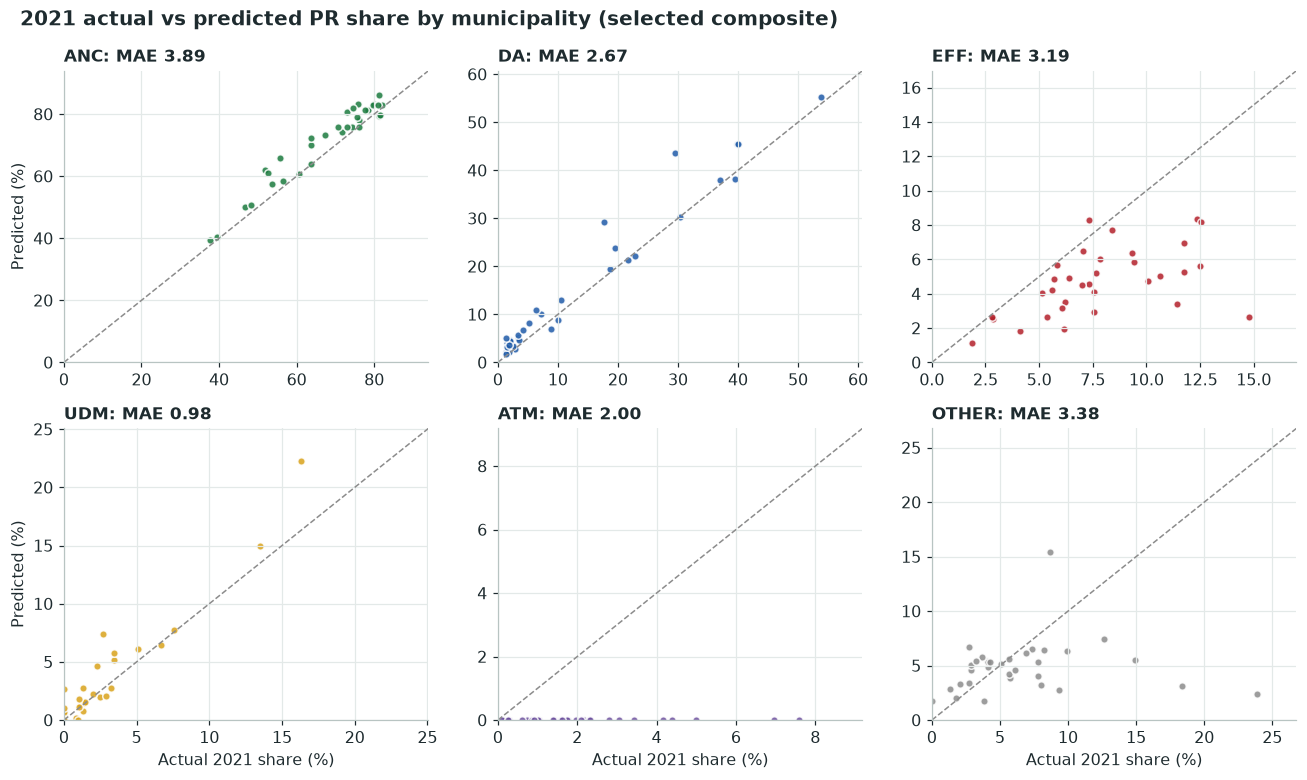

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.4))
x = np.arange(len(C.PARTIES)); w = .27
for k, (lab, s, col) in enumerate([("Selected", sum_sel, C.TEAL), ("No change", sum_nc, "#B8C4C2"), ("Last swing", sum_ls, C.ALOE)]):
    ax.bar(x + (k - 1) * w, [s[f"MAE_{p}"] for p in C.PARTIES], w, color=col, label=f"{lab} (overall {s['OverallMAE']:.2f})")
ax.set_xticks(x); ax.set_xticklabels(C.PARTIES); ax.set_ylabel("2021 MAE (pts)"); ax.legend()
ax.set_title("2021 test error by party", pad=22)
subtitle(ax, "Selected composite beats 'no change' overall; 'last swing' helps the ANC but hurts the DA and OTHER")
save(fig, "party_test_2021", "phase5"); plt.show()

fig, axes = plt.subplots(2, 3, figsize=(12, 7.2))
for ax, p in zip(axes.ravel(), C.PARTIES):
    a, b = comp_sel[f"Actual_{p}"], comp_sel[f"Pred_{p}"]
    ax.scatter(a, b, s=24, color=C.PARTY_COLORS[p], alpha=.85, edgecolor="white")
    hi = max(a.max(), b.max()) * 1.08 + 1
    ax.plot([0, hi], [0, hi], ls="--", color=C.GREY, lw=1); ax.set(xlim=(0, hi), ylim=(0, hi))
    ax.set_title(f"{p}: MAE {sum_sel['MAE_' + p]:.2f}", fontsize=11)
for ax in axes[1]: ax.set_xlabel("Actual 2021 share (%)")
for ax in axes[:, 0]: ax.set_ylabel("Predicted (%)")
fig.suptitle("2021 actual vs predicted PR share by municipality (selected composite)", x=.02, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout(); save(fig, "party_actual_vs_predicted_2021", "phase5"); plt.show()

**Interpretation.**

- The selected composite has an overall error of about **2.7 points** per party share, against 2.9 for "no change". Most of the gain comes from the OTHER category.
- **ATM** (2.0 points) and **EFF** errors are irreducible with this approach: ATM's entire 2021 vote was new, and EFF's growth could not be validated.
- **"Last swing"** would have done better for the ANC (its decline continued) but much worse for the DA, whose 2011→2016 growth reversed. That is why it is offered in Notebook 06 as a clearly labelled *alternative scenario*, not as the validated method.

### Identifying the largest party

In [7]:
lead = comp_sel[["MuniCode", "ActualLeader", "PredLeader", "ActualLeadGap_pts"]].copy()
lead["Municipality"] = lead["MuniCode"].map(C.muni_name)
print("Leader correct (selected):", sum_sel["LeaderMatches"], "of 33 | (no change):", sum_nc["LeaderMatches"], "of 33")
display(lead.sort_values("ActualLeadGap_pts").head(6).round(2))

Leader correct (selected): 33 of 33 | (no change): 33 of 33


,MuniCode,ActualLeader,PredLeader,ActualLeadGap_pts,Municipality
32,NMA,DA,DA,0.44,Nelson Mandela Bay
1,EC101,ANC,ANC,6.86,Dr Beyers Naude
14,EC131,ANC,ANC,14.13,Inxuba Yethemba
6,EC108,DA,DA,16.32,Kouga
7,EC109,ANC,ANC,18.77,Kou-Kamma
2,EC102,ANC,ANC,19.44,Blue Crane Route


The ANC led 31 municipalities and the DA 2 (Kouga and Nelson Mandela Bay). Because leadership rarely changes, identifying the leader is an **easy** test: the naive baseline also scores 33/33. The useful information is the *closeness* of the contest. Nelson Mandela Bay was decided by about 0.4 points in 2021, far inside the model's typical error, so for such places the honest statement is "too close to call".

### Note on the earlier prototype

The prototype picked each party's method by its 2021 error and then reported that same 2021 error (2.502) and 32/33 leaders. Choosing on the test set makes the reported error optimistic, and its 32/33 was below the 33/33 of the do-nothing baseline. The figures above replace it.

In [8]:
out = C.DIRS["phase5"]
methodology = pd.DataFrame([
    ["Target", "Municipal PR vote share by category (ANC, DA, EFF, UDM, ATM, OTHER), via swing"],
    ["Validation", "Rolling origin: folds 2011 and 2016 validation, 2021 test"],
    ["Selection rule", "Per party, lowest mean validation MAE where the party existed; otherwise No change"],
    ["Selected methods", "; ".join(f"{k}: {v}" for k, v in selected.items())],
    ["Composition", "Clip at 0, rescale to 100% per municipality"],
    ["2021 test overall MAE", f"{sum_sel['OverallMAE']:.3f} pts (No change: {sum_nc['OverallMAE']:.3f})"],
    ["2021 leader identified", f"{sum_sel['LeaderMatches']}/33 (No change: {sum_nc['LeaderMatches']}/33)"],
], columns=["Item", "Value"])
files = {"party_scores.csv": scores, "party_selected_methods.csv": methods,
         "party_backtest_2021_composition.csv": comp_sel, "party_backtest_summary.csv": summary,
         "provincial_pr_shares_by_year.csv": prov.reset_index(), "phase5_methodology.csv": methodology}
for name, df in files.items():
    df.to_csv(out / name, index=False); print(f"Saved {name:40s} {len(df):4d} rows")

Saved party_scores.csv                           78 rows
Saved party_selected_methods.csv                  6 rows
Saved party_backtest_2021_composition.csv        33 rows
Saved party_backtest_summary.csv                  4 rows
Saved provincial_pr_shares_by_year.csv            5 rows
Saved phase5_methodology.csv                      7 rows


## Summary

- Validated party-support methods are mostly **"no change"**, with a random forest for OTHER; the composite beats the baseline modestly (2.69 against 2.93 points).
- Leader identification is not a demanding test here; **contest closeness** is the informative output.
- New parties (EFF, ATM, and any formed after 2021) are the main source of error and cannot be learned from municipal history.

**Limitations.** Four transitions; parties grouped into six categories; coalitions, candidates and campaigns are not modelled; no information after 2021 (for example the 2024 national and provincial election) is used. Municipality-level shares say nothing about how individual groups vote.

**Next:** Notebook 06 combines both validated models into 2026 scenarios.

## References

Citations were compiled by the team; verify page/URL details before final submission.

- Electoral Commission of South Africa (IEC). Municipal (Local Government) Election results, detailed downloads 2000, 2006, 2011, 2016, 2021. https://results.elections.org.za/home/downloads/me-results
- Hyndman, R.J. & Athanasopoulos, G. (2021). Forecasting: Principles and Practice, 3rd ed., ch. 5.10 (time-series cross-validation). https://otexts.com/fpp3/
- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. JMLR 12, 2825-2830.
- Laakso, M. & Taagepera, R. (1979). 'Effective' number of parties: a measure with application to West Europe. Comparative Political Studies, 12(1), 3-27.

In [9]:
# Software used in this notebook (versions recorded for reproducibility)
import platform
from importlib.metadata import version, PackageNotFoundError
rows = [("python", platform.python_version())]
for pkg in ['pandas', 'numpy', 'matplotlib', 'scikit-learn', 'statsmodels', 'shapely', 'xlrd', 'nbformat']:
    try:
        rows.append((pkg, version(pkg)))
    except PackageNotFoundError:
        rows.append((pkg, "not installed"))
display(pd.DataFrame(rows, columns=["Package", "Version"]))

,Package,Version
0,python,3.13.15
1,pandas,3.0.6
2,numpy,2.5.3
3,matplotlib,3.11.2
4,scikit-learn,1.9.1
5,statsmodels,0.15.0
6,shapely,2.1.2
7,xlrd,2.0.2
8,nbformat,5.11.1
